# PCA Image Compression
### Using Singular Value Decomposition (SVD)

---

**Principal Component Analysis (PCA)** is one of the most important techniques in data science and signal processing. In this notebook we apply it to **image compression** — reducing the storage size of an image while preserving its visual quality.

#### Learning objectives
1. Understand the mathematical foundation of PCA and SVD
2. Implement PCA compression from scratch using NumPy
3. Measure quality loss with PSNR, MSE, and SSIM
4. Visualize the trade-off between compression ratio and image quality
5. Compare behavior across different image types

## 1. Mathematical Background

### 1.1 What is PCA?

Given a data matrix **X** of shape *(n_samples × n_features)*, PCA finds an orthogonal basis — the **principal components** — that best explain the variance in the data.

The key insight: most natural images have **highly correlated pixels**. Adjacent pixels tend to have similar values, so the actual information content is much lower than H×W suggests.

### 1.2 SVD — the engine of PCA

Any matrix **X** can be decomposed as:

$$X = U \Sigma V^T$$

where:
- **U** *(H × H)*: left singular vectors (row-space basis)
- **Σ** *(H × W)*: diagonal matrix of singular values (sorted descending)
- **V^T** *(W × W)*: right singular vectors (column-space basis)

### 1.3 Compression via truncated SVD

Keeping only the top **k** singular values:

$$\hat{X}_k = U_k \Sigma_k V_k^T$$

This is the **best rank-k approximation** of X (Eckart–Young theorem).

### 1.4 Compression ratio

| | Values stored |
|---|---|
| Original | H × W |
| Compressed | k(H + W + 1) |
| Ratio | HW / k(H+W+1) |

For a 256×256 image at k=30: ratio ≈ **4.3×**

### 1.5 Quality metrics

| Metric | Formula | Interpretation |
|---|---|---|
| MSE | mean((X - X̂)²) | Lower = better |
| PSNR | 10·log₁₀(255²/MSE) | Higher = better, >30 dB good |
| SSIM | structural similarity | 0–1, higher = better |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os, warnings
warnings.filterwarnings('ignore')

from pca_compression import (
    compress_image, compress_channel,
    compute_metrics_across_k,
    generate_test_image, load_image, save_image,
    plot_compression_comparison, plot_metrics_vs_k,
    plot_scree, plot_full_analysis
)

os.makedirs('outputs', exist_ok=True)
print('✓ Setup complete')

✓ Setup complete


## 2. Load / Generate Test Image

Image shape : (1025, 2048, 3)
Dtype       : uint8
Value range : [0, 255]


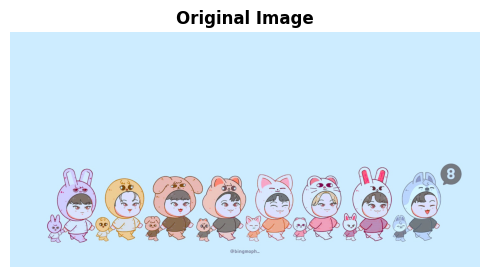

In [3]:
image = load_image('wp11990624-skzoo-desktop-wallpapers.jpg')  # replace with your file name

print(f'Image shape : {image.shape}')
print(f'Dtype       : {image.dtype}')
print(f'Value range : [{image.min()}, {image.max()}]')

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title('Original Image', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Step-by-Step PCA (Single Channel)

In [4]:
# Extract R channel for demonstration
channel = image[:, :, 0].astype(np.float64)
H, W = channel.shape
K = 30  # number of components

print(f'Channel shape : {channel.shape}')
print(f'Using k = {K} components\n')

# Step 1: Mean-center the rows
row_means = channel.mean(axis=1, keepdims=True)
X_centered = channel - row_means
print(f'Step 1 — Mean-centered X:  {X_centered.shape}')

# Step 2: SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
print(f'Step 2 — SVD:')
print(f'         U  shape : {U.shape}')
print(f'         S  shape : {S.shape}  (singular values)')
print(f'         Vt shape : {Vt.shape}')

# Step 3: Truncate to k components
Uk  = U[:, :K]
Sk  = np.diag(S[:K])
Vtk = Vt[:K, :]
print(f'Step 3 — Truncated to k={K}:')
print(f'         Uk  shape : {Uk.shape}')
print(f'         Sk  shape : {Sk.shape}')
print(f'         Vtk shape : {Vtk.shape}')

# Step 4: Reconstruct
X_reconstructed = Uk @ Sk @ Vtk + row_means
X_reconstructed = np.clip(X_reconstructed, 0, 255)
print(f'Step 4 — Reconstructed : {X_reconstructed.shape}')

# Compression stats
original_vals    = H * W
compressed_vals  = K * (H + W + 1)
ratio            = original_vals / compressed_vals
var_exp          = (S[:K]**2).sum() / (S**2).sum() * 100

print(f'\nOriginal values   : {original_vals:,}')
print(f'Compressed values : {compressed_vals:,}')
print(f'Compression ratio : {ratio:.2f}x')
print(f'Variance explained: {var_exp:.1f}%')

Channel shape : (1025, 2048)
Using k = 30 components

Step 1 — Mean-centered X:  (1025, 2048)
Step 2 — SVD:
         U  shape : (1025, 1025)
         S  shape : (1025,)  (singular values)
         Vt shape : (1025, 2048)
Step 3 — Truncated to k=30:
         Uk  shape : (1025, 30)
         Sk  shape : (30, 30)
         Vtk shape : (30, 2048)
Step 4 — Reconstructed : (1025, 2048)

Original values   : 2,099,200
Compressed values : 92,220
Compression ratio : 22.76x
Variance explained: 65.5%


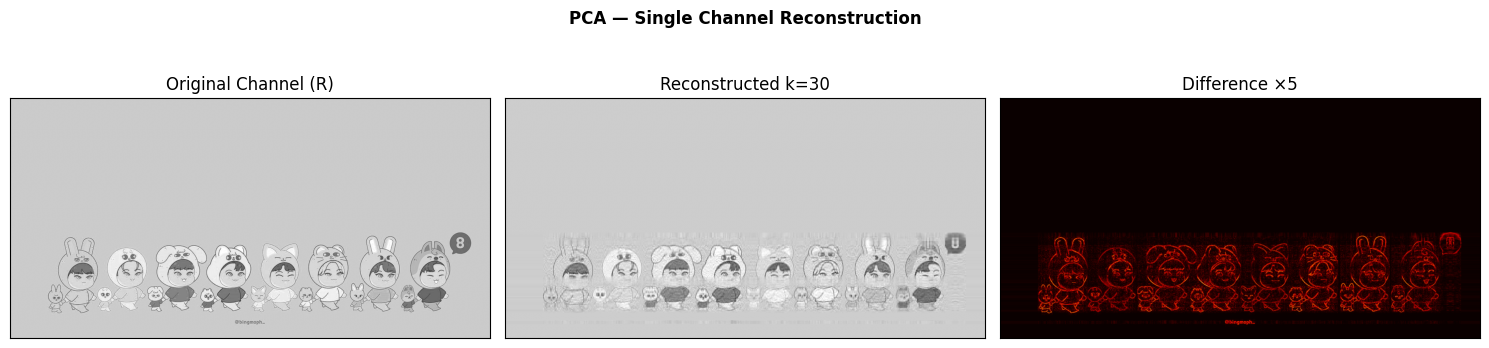

In [5]:
# Visualize the single-channel result
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(channel, cmap='gray'); axes[0].set_title('Original Channel (R)')
axes[1].imshow(X_reconstructed, cmap='gray'); axes[1].set_title(f'Reconstructed k={K}')
diff = np.abs(channel - X_reconstructed)
axes[2].imshow(diff * 5, cmap='hot'); axes[2].set_title('Difference ×5')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('PCA — Single Channel Reconstruction', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Full RGB Compression

In [6]:
k = 30
compressed, metrics, singular_vals = compress_image(image, k=k)

print('── Compression Metrics ──────────────────────')
for key, val in metrics.items():
    if key != 'var_explained':
        print(f'  {key:<25} {val}')

print('\n── Per-Channel Variance ─────────────────────')
for ch, v in metrics['var_explained'].items():
    print(f'  Channel {ch}: {v*100:.1f}%')

── Compression Metrics ──────────────────────
  k                         30
  image_shape               (1025, 2048)
  n_channels                3
  original_size_px          6297600
  compressed_size_px        276660
  compression_ratio         22.762958143569726
  mse                       201.94025724085367
  psnr_db                   25.078574557194347
  ssim                      0.8731181815355248
  var_explained_mean        0.7181279792052365

── Per-Channel Variance ─────────────────────
  Channel R: 65.5%
  Channel G: 72.7%
  Channel B: 77.3%


## 5. Multi-k Comparison

Saved → outputs/comparison.png


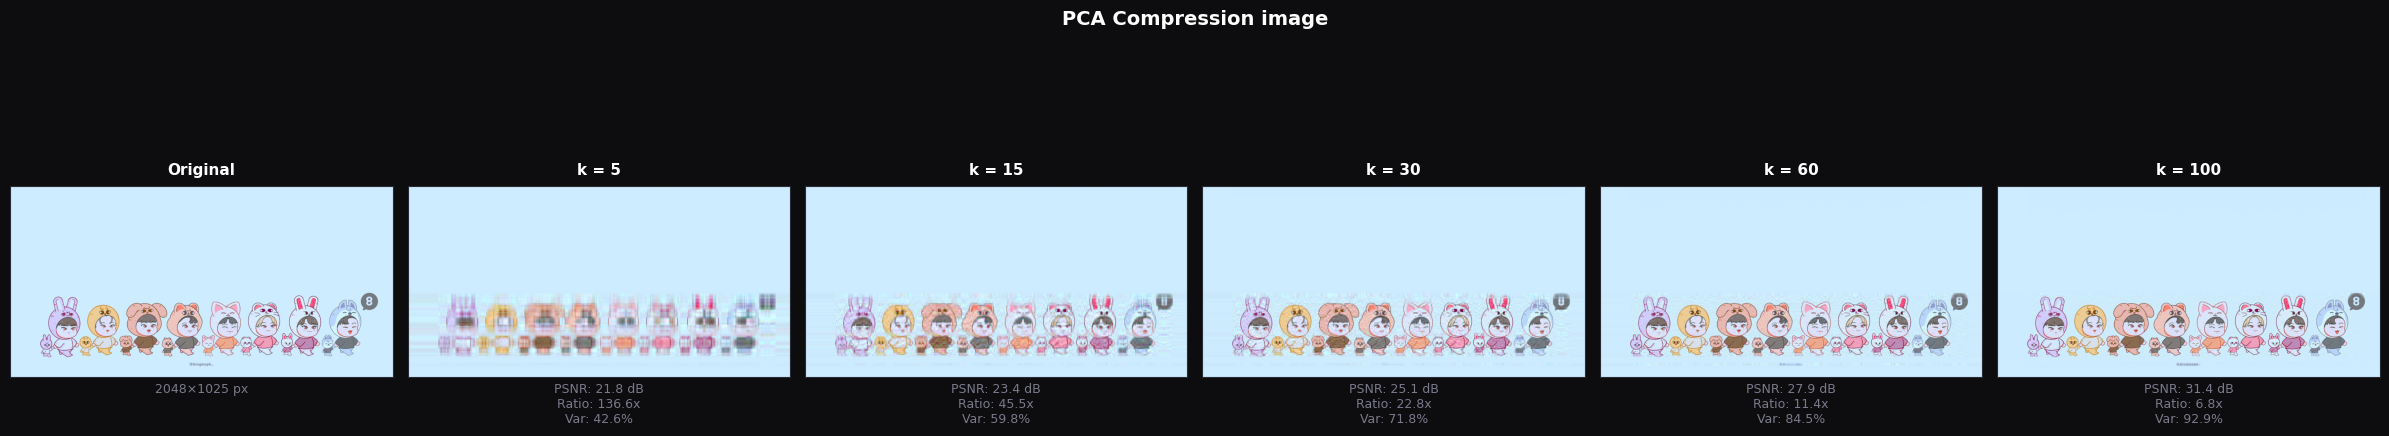

In [8]:
plot_compression_comparison(
    image,
    k_values=[5, 15, 30, 60, 100],
    title=f'PCA Compression image',
    save_path='outputs/comparison.png'
)

## 6. Quality Metrics vs k

Computing metrics for 34 values of k…
Saved → outputs/metrics_vs_k.png


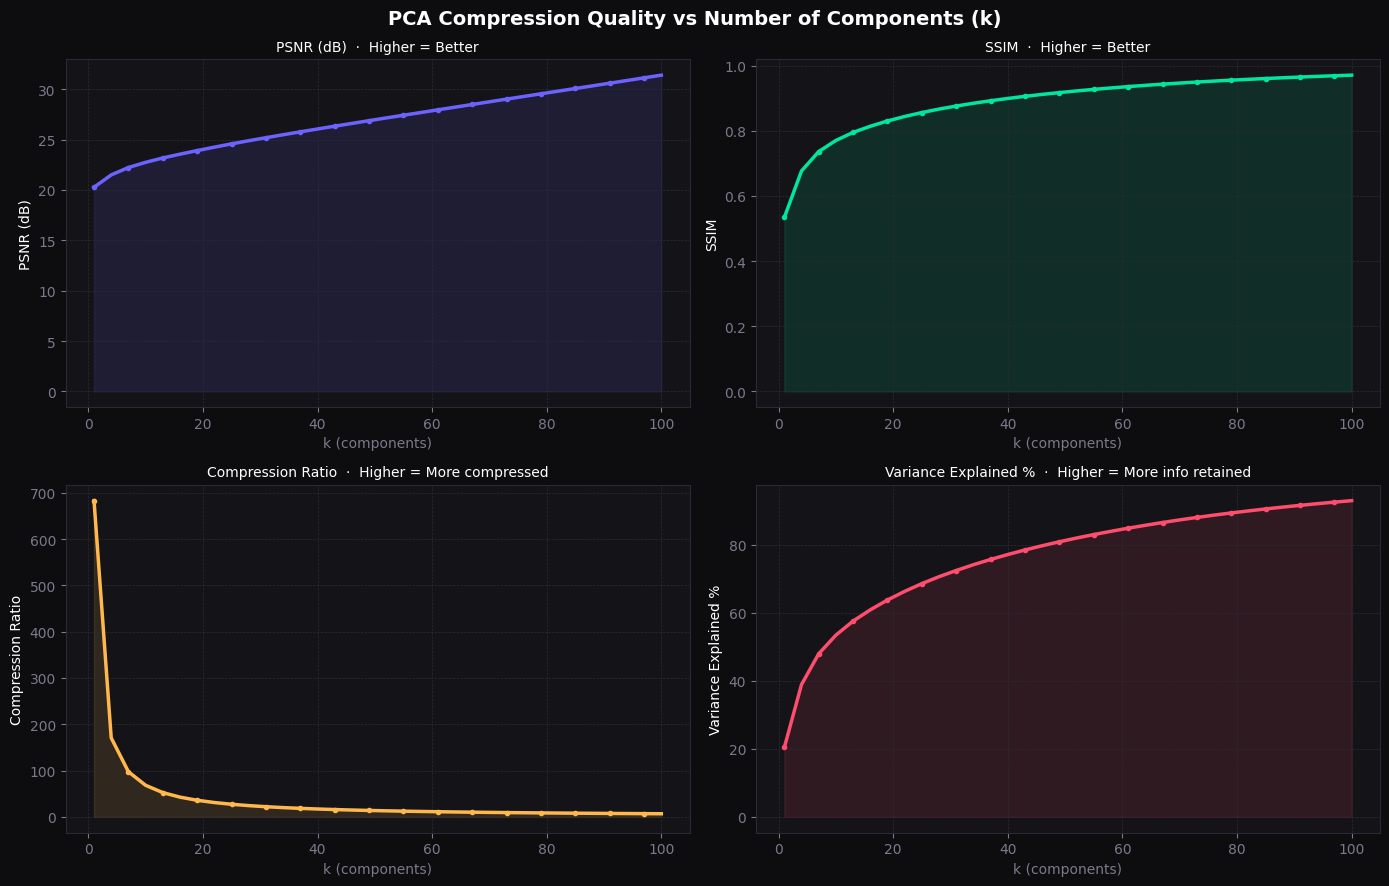

In [ ]:
plot_metrics_vs_k(
    image,
    k_range=range(1, 101, 3),
    save_path='outputs/metrics_vs_k.png'
)

## 7. Scree Plot — Eigenvalue Spectrum

Saved → outputs/scree.png


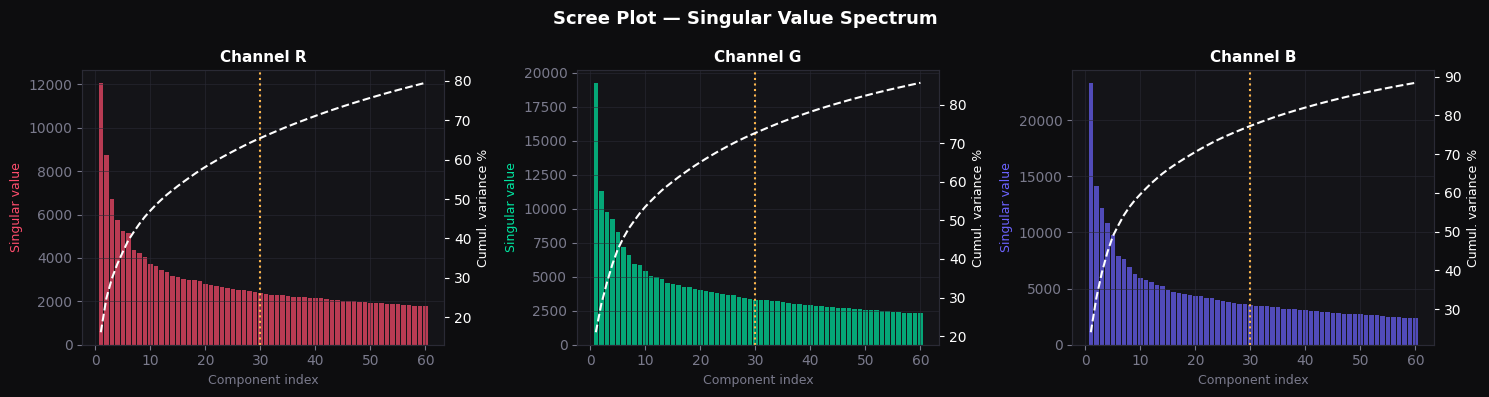

In [11]:
_, _, singular_vals = compress_image(image, k=30)
plot_scree(
    singular_vals,
    channel_names=['R', 'G', 'B'],
    k=30,
    save_path='outputs/scree.png'
)

## 8. Full Analysis Dashboard

Saved → outputs/full_analysis.png


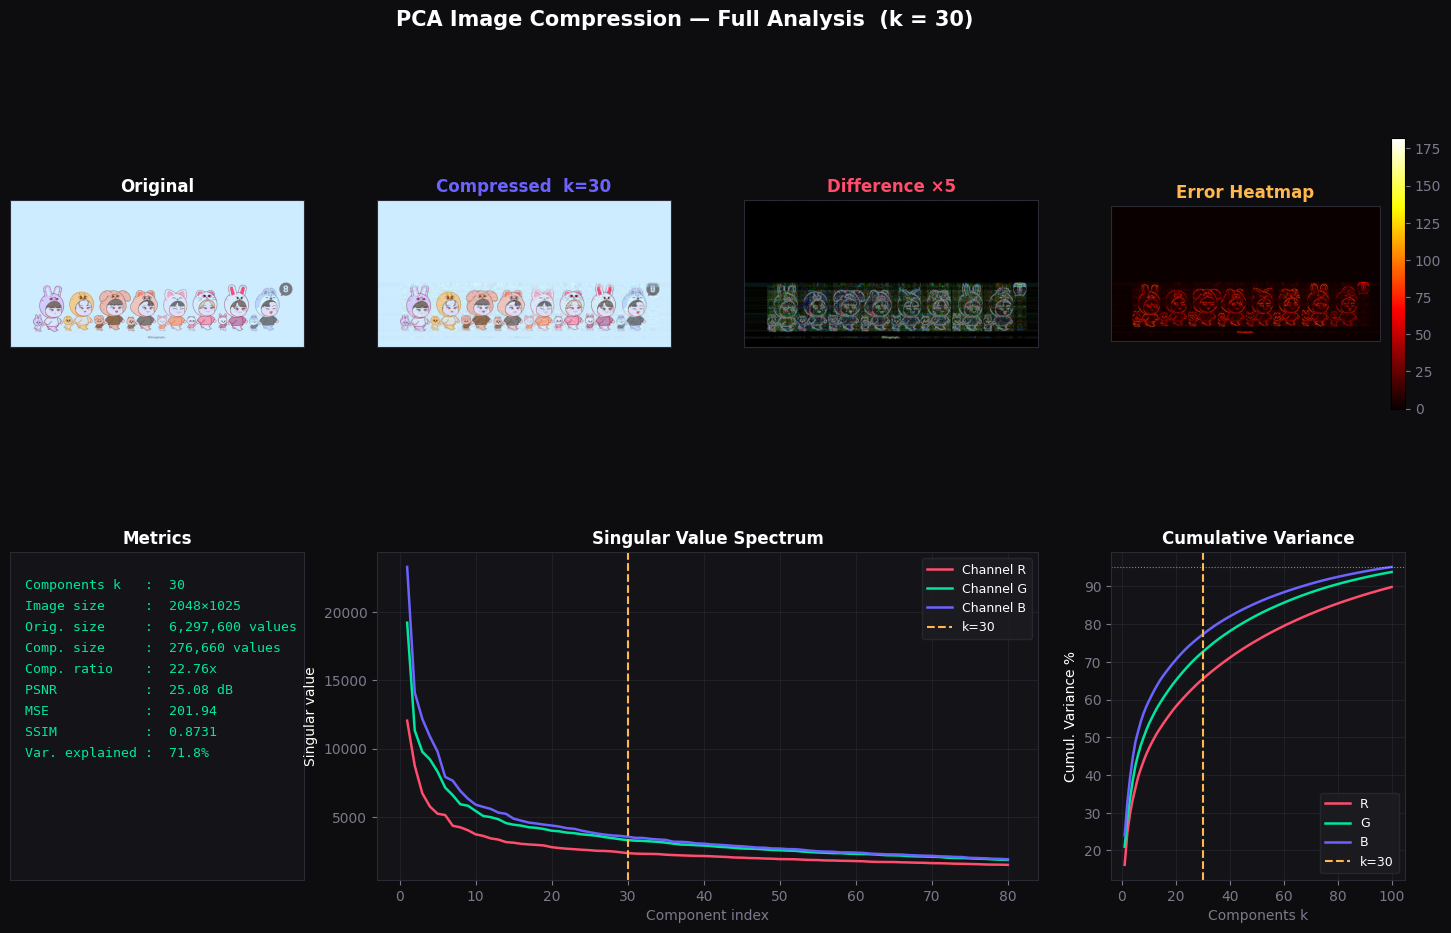

In [12]:
metrics = plot_full_analysis(image, k=30, save_path='outputs/full_analysis.png')

## 9. Compare Image Types

## 10. Find Optimal k for Target Quality

## 11. Summary

| Observation | Explanation |
|---|---|
| Smooth images compress well | Low-freq content captured by first few PCs |
| Noise images compress poorly | Random signal = no dominant directions |
| PSNR rises fast then plateaus | Diminishing returns after elbow in scree |
| Compression ratio falls with k | More components = more stored values |
| Scree 'elbow' = good k choice | Point where adding components gives little gain |

### Key takeaways
- PCA compression is **lossless when k = min(H, W)** — the full rank restores the original perfectly
- The **scree plot elbow** visually identifies the best k trade-off
- **PSNR > 30 dB** is generally considered visually acceptable
- PCA compresses the **spatial** redundancy; JPEG additionally uses DCT + quantization per block

In [15]:
# Save final compressed images at multiple k values
for k in [5, 10, 20, 30, 50, 100]:
    comp, m, _ = compress_image(image, k)
    save_image(comp, f'outputs/compressed_k{k:03d}.png')

save_image(image, 'outputs/original.png')
print('\n✓ All outputs saved to ./outputs/')

Saved → outputs/compressed_k005.png
Saved → outputs/compressed_k010.png
Saved → outputs/compressed_k020.png
Saved → outputs/compressed_k030.png
Saved → outputs/compressed_k050.png
Saved → outputs/compressed_k100.png
Saved → outputs/original.png

✓ All outputs saved to ./outputs/
